In [181]:
import glob as glob
import json
import matplotlib.pyplot as plt


## Displaying Score vs. Epsilon

In [199]:
## Helper functions

def prettify_metric(metric : str):
    """
    Turn metric into a presentable label.
    
    Ex: falsePositiveRate -> False Positive Rate
    """
    words = []
    temp_word = ""
    for i, letter in enumerate(metric): 
        if (letter.isupper()):
            words.append(temp_word)
            temp_word = ""
        temp_word += letter
    else:
        words.append(temp_word)

    words = [word.capitalize() for word in words]
    return " ".join(words)

def load_data(folder_path : str, x_metric, y_metric : str, label : str = None):
    """
    Load data for a certain `metric` from an inputted `folder_path`.

    Input: folder_path, metric, label

    Return: {x, y, label (inputted, if needed for a plt legend)}
    """
    filenames = glob.glob(folder_path)

    len(filenames)

    x, y= [], []

    for filename in filenames:
        with open(filename, 'r') as file:
            data = json.load(file)
            x.append(data['kwargs'][x_metric])
            if y_metric == "timeElapsedSec":
                y.append(data[y_metric])
            else:
                y.append(data['metrics'][y_metric])
    print(len(x), len(y))
    x, y = zip(*sorted(zip(x, y))) # order the data correctly
    return {'x': x, 'y': y, 'label': label}

def prettify_plot(title, display_metric, x_max : float = 0.31, limit : bool = True):
    """
    Provide the rest of the graph after calling plt for 
    grahping data

    Inputs: 
    - title, metric (for axis) - should be in correct format already
    - limit - whether to limit the graph to [0, 1]
    """
    
    plt.title(title)
    plt.xlabel("Epsilon")
    plt.ylabel(f"{display_metric} Score")
    if limit:
        plt.ylim(0, 1)
    plt.xlim(0, x_max)
    plt.grid(True)

    # Add flare to the graph
    plt.legend()
    plt.minorticks_on()
    plt.grid(True, which='minor', linewidth=0.5)
    plt.grid(True, which='major', linewidth=1.0)

30 30
30 30
30 30
30 30
30 30
29 29


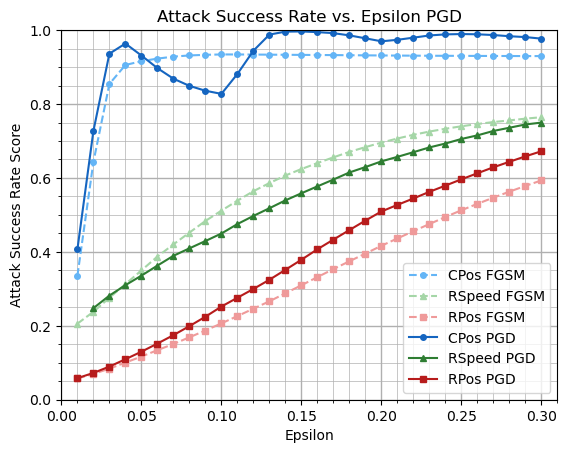

In [ ]:
## Plot data comparing between FGSM vs. PGD
# Inputs
attack = "pgd-y-10"
metric = "f1"

# Plot data
data = {}
# fgsm
data[f"cpos-fgsm"] = load_data(folder_path=f"../final_data/constpos/fgsm-y/*", 
                                  metric=metric, 
                                  label="CPos FGSM")
data[f"rpos-fgsm"] = load_data(folder_path=f"../final_data/randpos/fgsm-y/*", 
                                  metric=metric, 
                                  label="RPos FGSM")
data[f"rspeed-fgsm"] = load_data(folder_path=f"../final_data/randspeed/fgsm-y/*", 
                                  metric=metric, 
                                  label="RSpeed FGSM")
# pgd
data[f"cpos-pgd"] = load_data(folder_path=f"../final_data/constpos/pgd-y-10/*", 
                                  metric=metric, 
                                  label="CPos PGD")
data[f"rpos-pgd"] = load_data(folder_path=f"../final_data/randpos/pgd-y-10/*", 
                                  metric=metric, 
                                  label="RPos PGD")
data[f"rspeed-pgd"] = load_data(folder_path=f"../final_data/randspeed/pgd-y-10/*", 
                                  metric=metric, 
                                  label="RSpeed PGD")

# FGSM: dashed lines, lighter shades
plot_data(data, "cpos-fgsm",   "#64B5F6", "o", "--")  # light blue,  circle
plot_data(data, "rspeed-fgsm", "#A5D6A7", "^", "--")  # light green, triangle
plot_data(data, "rpos-fgsm",   "#EF9A9A", "s", "--")  # light red,   square

# PGD: solid lines, darker shades of the same colors
plot_data(data, "cpos-pgd",    "#1565C0", "o", "-")   # dark blue,   circle
plot_data(data, "rspeed-pgd",  "#2E7D32", "^", "-")   # dark green,  triangle
plot_data(data, "rpos-pgd",    "#B71C1C", "s", "-")   # dark red,    square

# Plot the rest
display_metric  = prettify_metric(metric)
display_title = f"{display_metric} vs. Epsilon PGD"
prettify_plot(display_title, display_metric)

30 30
30 30
30 30


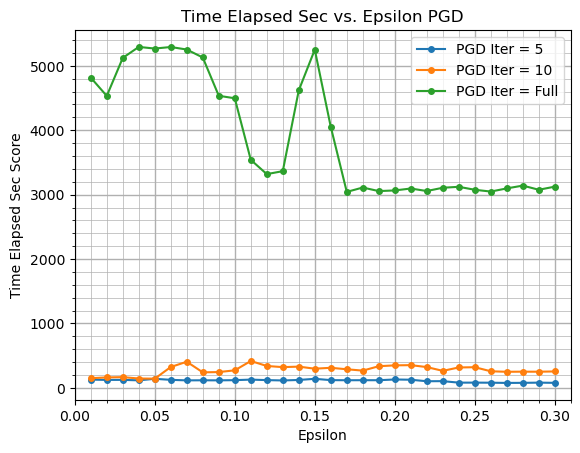

In [194]:
## Plot data comparing between PGD iters
# Load data
for metric in ["timeElapsedSec"]:
    for scale in ["5", "10", "full"]:
        data[f"cpos-{scale}"] = load_data(f"../data_old/constpos-old/pgd-y-{scale}/*", metric, scale)

# Plot the rest
plt.plot(data["cpos-5"]['x'], data["cpos-5"]['y'],
         marker="o", markersize=4, label = "PGD Iter = 5")
plt.plot(data["cpos-10"]['x'], data["cpos-10"]['y'],
         marker="o", markersize=4, label = "PGD Iter = 10")
plt.plot(data["cpos-full"]['x'], data["cpos-full"]['y'],
         marker="o", markersize=4, label = "PGD Iter = Full")

# Plot the rest
display_metric  = prettify_metric(metric)
display_title = f"{display_metric} vs. Epsilon PGD"
prettify_plot(display_title, display_metric, limit=False)

30 30


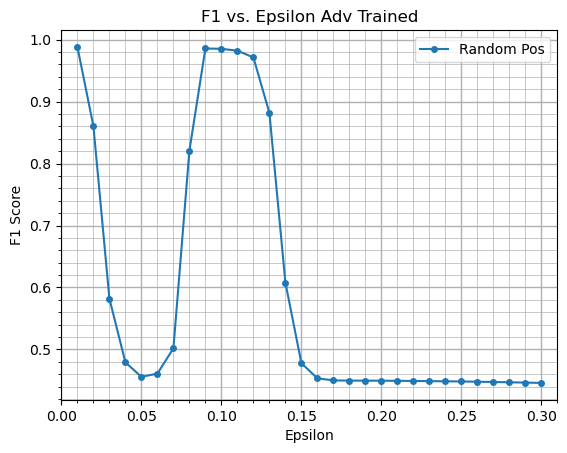

In [ ]:
## Load Plot for metric vs epsilon and different attack datasetsß
# Inputs
attack = "test"
x_metric = "eps"
y_metric = "f1"

# Load data
data = {}
data["rpos"] = load_data(f"../adv_trained/randpos/{attack}/*", 
                         x_metric = x_metric,
                         y_metric = y_metric)
# data["cpos"] = load_data(f"../final_data/constpos/{attack}/*",  
#                          x_metric = x_metric,
#                          y_metric = y_metric)
# data["rspeed"] = load_data(f"../final_data/randspeed/{attack}/*",  
#                          x_metric = x_metric,
#                          y_metric = y_metric)

# Plot Epsilon
# plt.plot(data["cpos"]['x'], data["cpos"]['y'],
#          marker="o", markersize=4, label = "Constant Pos")
plt.plot(data["rpos"]['x'], data["rpos"]['y'],
         marker="o", markersize=4, label = "Random Pos")
# plt.plot(data["rspeed"]['x'], data["rspeed"]['y'],
#          marker="o", markersize=4, label = "Random Speed")

# Plot the rest
display_metric  = prettify_metric(metric)
display_title = f"{display_metric} vs. Epsilon FGSM Adv Trained"
prettify_plot(display_title, display_metric, 
               limit=False)

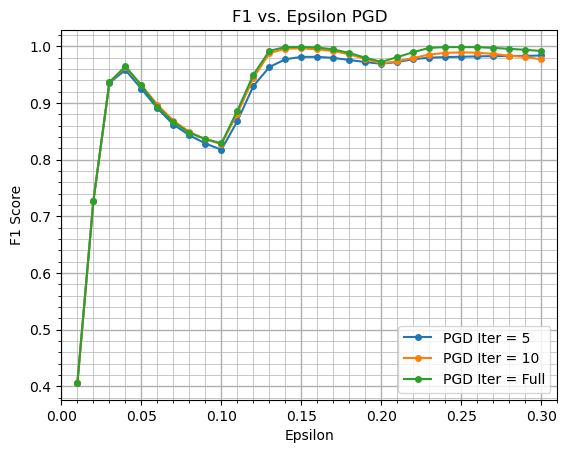

In [ ]:
## Leftover, potential useful plotting code 

# def plot_data(in_data, key, color=None, marker : str ="o", linestyle="-"):
#     plt.plot(in_data[key]['x'], in_data[key]['y'],
#              marker=marker, markersize=4, label=in_data[key]["label"],
#              color=color, linestyle=linestyle)



# plot multiple
# for metric in ["f1", "attackSuccessRate", "falsePositiveRate"]:
#     for scale in ["5", "10", "full"]:
#         label = f"cpos-{metric}-{scale}"
#         # data[label] = load_data(f"../final_data/constpos/pgd-y-{scale}/*", metric, label)
#         plt.plot(data[label]['x'], data[label]['y'], 
#                  marker="o", markersize=4, label = data[label]['label'])


## JSMA: F1 vs. Gamma

In [7]:
# 1. Load data
foldername = "../asr_data/jsma-norm_end-5000/*"
filenames = glob.glob(foldername)

len(filenames)

10

In [12]:
x, y= [], []

for filename in filenames:
    with open(filename, 'r') as file:
        data = json.load(file)
        if not 'kwargs' in data.keys(): 
            continue
        x.append(data['kwargs']['gamma'])
        y.append(data['attackSuccessRate'])
x, y = zip(*sorted(zip(x, y)))
x, y



((0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0),
 (0.04983202687569989,
  0.10526315789473684,
  0.1875699888017917,
  0.19260918253079506,
  0.20044792833146696,
  0.20212765957446807,
  0.20212765957446807,
  0.20212765957446807,
  0.20212765957446807,
  0.20212765957446807))

/tmp/ipykernel_1923048/3043124287.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


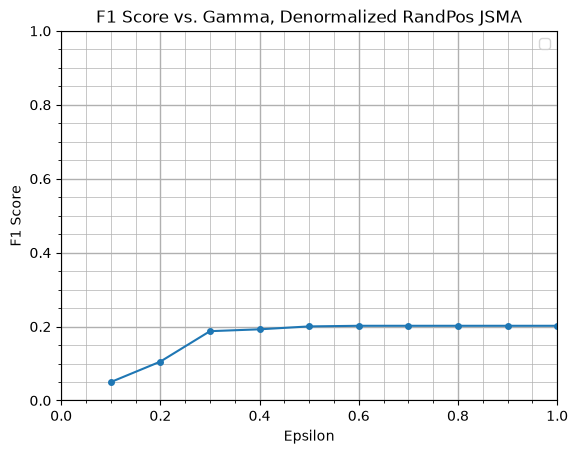

In [ ]:
# 2. Create the line plot
plt.plot(x, y, marker="o", markersize=4)
# plt.scatter(norm_x, norm_y, color='red', marker="o", label="Normalized")

# 3. Add titles and labels
plt.title("ASR vs. Gamma, Normalized Collapsed RandPos JSMA")
plt.xlabel("Epsilon")
plt.ylabel("Attack Success Rate")
plt.ylim(0, 1)
plt.xlim(0, 1)

plt.legend()
plt.minorticks_on()
plt.grid(True, which='minor', linewidth=0.5)
plt.grid(True, which='major', linewidth=1.0)


# 4. Display the graph

## Displaying F1 Score vs. Run type

In [22]:
cat_vals = {}
for filename in filenames:
    with open(filename, 'r') as file:
        data = json.load(file)
        print(data)
        norm_type = "Denorm" if "denorm" in filename else "Norm"
        
        # Loop through each run and average the results
        for run in (data["benign"]):
            wrapper_type = "Wrapper" if run["wrapper"] else "Og"
            collapsed_type = "Collapsed" if run["collapsedOutput"] else "Uncollapsed"
            key = f"{norm_type}-{wrapper_type}-{collapsed_type}"

            # if not key in cat_vals.keys():
            #     cat_vals[key] = []

            cat_vals[key] = (run["f1"])


cat_vals

{'benign': [{'wrapper': False, 'collapsedOutput': False, 'accuracy': 0.9828824723807696, 'precision': 0.9641379419885481, 'recall': 0.978858930529575, 'f1': 0.9714426699563232}, {'wrapper': False, 'collapsedOutput': True, 'accuracy': 0.9832112459326462, 'precision': 0.9643128342104006, 'recall': 0.9797491232802805, 'f1': 0.9719696949422882}, {'wrapper': True, 'collapsedOutput': False, 'accuracy': 0.9828824723807696, 'precision': 0.9830044252696218, 'recall': 0.9828824723807696, 'f1': 0.9829195656898114}, {'wrapper': True, 'collapsedOutput': True, 'accuracy': 0.9961931171558177, 'precision': 0.9961990861326315, 'recall': 0.9961931171558177, 'f1': 0.9961883773969892}]}
{'benign': [{'wrapper': False, 'collapsedOutput': False, 'accuracy': 0.9917490823408723, 'precision': 0.9921024389045001, 'recall': 0.9800296735905044, 'f1': 0.9860291034334886}, {'wrapper': False, 'collapsedOutput': True, 'accuracy': 0.9917490823408723, 'precision': 0.9921024389045001, 'recall': 0.9800296735905044, 'f1': 

{'Denorm-Og-Uncollapsed': 0.9714426699563232,
 'Denorm-Og-Collapsed': 0.9719696949422882,
 'Denorm-Wrapper-Uncollapsed': 0.9829195656898114,
 'Denorm-Wrapper-Collapsed': 0.9961883773969892,
 'Norm-Og-Uncollapsed': 0.9860291034334886,
 'Norm-Og-Collapsed': 0.9860291034334886,
 'Norm-Wrapper-Uncollapsed': 0.9917344098986437,
 'Norm-Wrapper-Collapsed': 0.997697250661112}

In [7]:
cat_vals = {"Denorm-Wrapper-Collapsed": 0.9557423970602369, "Norm-Wrapper-Collapsed": 0.15478531634773934}

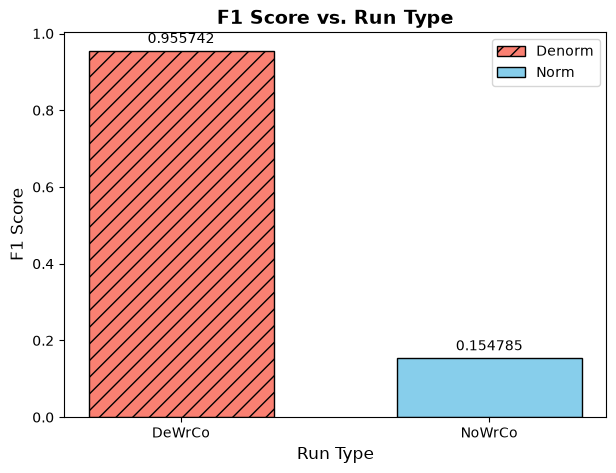

In [8]:
cats = list(cat_vals.keys())
vals = list(cat_vals.values())

color_map = {'Denorm': 'salmon', 'Norm': 'skyblue'}
hatch_map = {'Denorm': '//', 'Norm': ''}

colors  = [color_map['Denorm' if k.startswith('Denorm') else 'Norm'] for k in cats]
hatches = [hatch_map['Denorm' if k.startswith('Denorm') else 'Norm'] for k in cats]

fig, ax = plt.subplots(figsize=(7, 5))

bar_cats = []

for k in cats:
    norm_type = "De" if "Denorm" in k else "No"
    wrapper_type = "Wr" if "Wrapper" in k else "Og"
    collapsed_type = "Un" if "Uncollapsed" in k else "Co"
    bar_cats.append(f"{norm_type}{wrapper_type}{collapsed_type}")

 
bars = ax.bar(bar_cats, vals, width=0.6, color=colors, hatch=hatches, edgecolor='black')
ax.bar_label(bars, padding=3)
# ax.set_ylim(0.96, 1.0)

ax.set_xlabel('Run Type', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score vs. Run Type', fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='salmon',  edgecolor='black', hatch='//', label='Denorm'),
    Patch(facecolor='skyblue', edgecolor='black', label='Norm'),
]
ax.legend(handles=legend_elements)


dict_keys(['Denorm-Wrapper-Uncollapsed', 'Denorm-Og-Uncollapsed', 'Denorm-Og-Collapsed', 'Denorm-Wrapper-Collapsed', 'Norm-Wrapper-Uncollapsed', 'Norm-Og-Uncollapsed', 'Norm-Og-Collapsed', 'Norm-Wrapper-Collapsed']) dict_values([0.9829195656898114, 0.9714426699563232, 0.9719696949422882, 0.9961883773969892, 0.9917344098986437, 0.9860291034334886, 0.9860291034334886, 0.997697250661112])


Text(0.5, 1.0, 'F1 Score vs. Run Type')

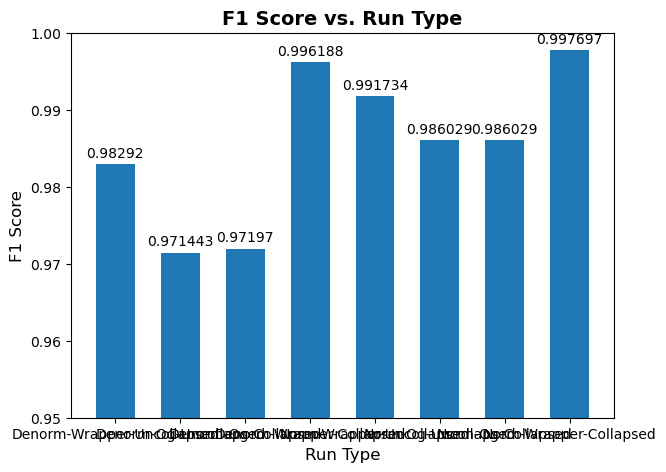

In [10]:
cats = cat_vals.keys()
vals = cat_vals.values()
print(cats, vals)
# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 5))

# Plot vertical bars
bars = ax.bar(cats, vals, width=0.6)
ax.bar_label(bars, padding=3)
ax.set_ylim(0.95, 1.0)

# Customizing labels and title
ax.set_xlabel('Run Type', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score vs. Run Type', fontsize=14, fontweight='bold')